# Experiment 18: Improve Autoencoder Performance Using Convolutional Layers on MNIST

**Objective:** To improve the performance of an autoencoder by using convolutional layers with the MNIST dataset.


## 1. Introduction

A basic autoencoder with dense layers works well for simple dimensionality reduction, but image data has spatial patterns that dense layers do not exploit efficiently. A **Convolutional Autoencoder (CAE)** uses convolution and pooling operations to learn better image features, leading to improved reconstruction quality.

In this experiment, we use the **MNIST handwritten digit dataset** and build a convolutional autoencoder to reconstruct the images with better accuracy than a simple dense autoencoder.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

print('Training data shape:', x_train.shape)
print('Testing data shape:', x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


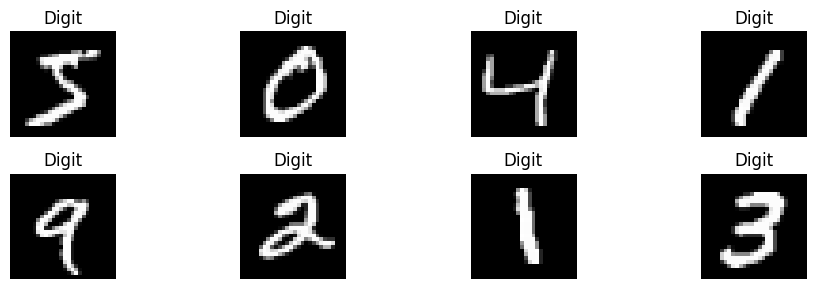

In [3]:
# Display some sample images
plt.figure(figsize=(10, 3))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title('Digit')
    plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

We normalize image pixel values to the range [0, 1] and reshape them to include a channel dimension.


In [4]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print('Reshaped training data:', x_train.shape)
print('Reshaped testing data:', x_test.shape)

Reshaped training data: (60000, 28, 28, 1)
Reshaped testing data: (10000, 28, 28, 1)


## 5. Build the Convolutional Autoencoder

The encoder compresses the image using convolution and pooling layers. The decoder reconstructs the image using convolution and upsampling layers.


In [5]:
input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same', name='encoded_layer')(x)

# Decoder
x = Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded_layer (MaxPooling2D)    │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the Model


In [6]:
history = autoencoder.fit(
    x_train, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test, x_test),
    verbose=1
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 72s 149ms/step - loss: 0.1298 - val_loss: 0.0798
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 70s 150ms/step - loss: 0.0773 - val_loss: 0.0744
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 152ms/step - loss: 0.0740 - val_loss: 0.0723
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 70s 149ms/step - loss: 0.0725 - val_loss: 0.0712
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 69s 147ms/step - loss: 0.0715 - val_loss: 0.0704
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 153ms/step - loss: 0.0707 - val_loss: 0.0698
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 72s 152ms/step - loss: 0.0701 - val_loss: 0.0693
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 148ms/step - loss: 0.0697 - val_loss: 0.0688
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 69s 147ms/step - loss: 0.0693 - val_loss: 0.0685
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 69s 148ms/step - loss: 0.0689 - val_loss: 0.0682


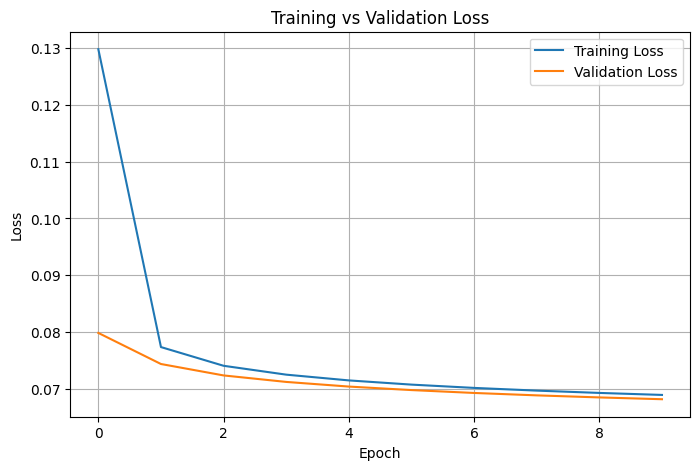

In [7]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

## 7. Reconstruct Images

Now we use the trained convolutional autoencoder to reconstruct test images.


In [8]:
decoded_imgs = autoencoder.predict(x_test)
print('Reconstructed image shape:', decoded_imgs.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Reconstructed image shape: (10000, 28, 28, 1)


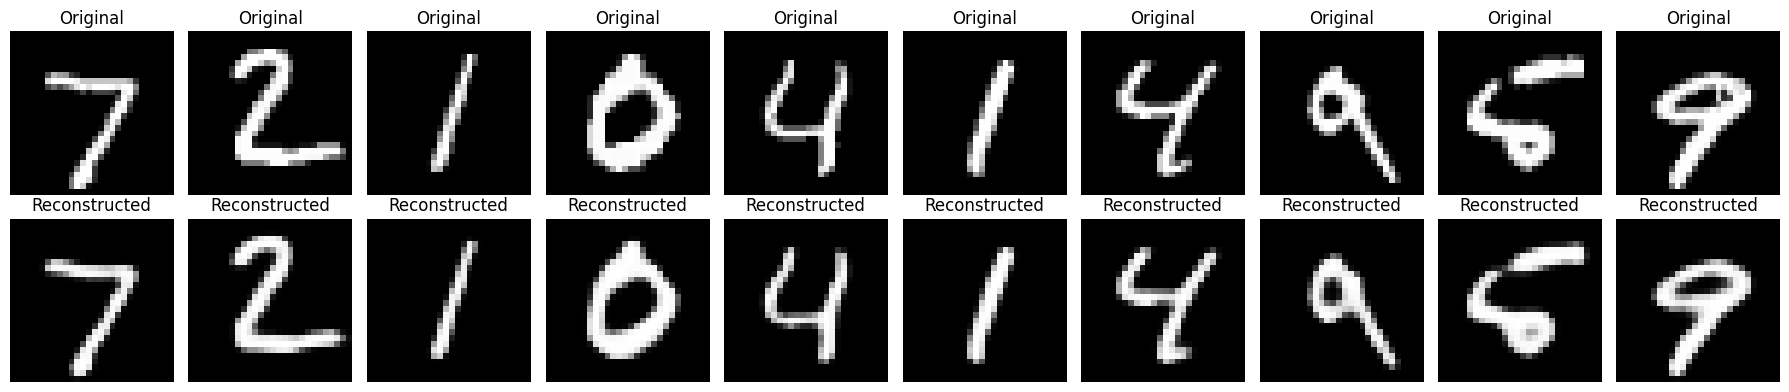

In [9]:
# Show original and reconstructed images
n = 10
plt.figure(figsize=(18, 4))
for i in range(n):
    # original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title('Original')
    plt.axis('off')

    # reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title('Reconstructed')
    plt.axis('off')

plt.tight_layout()
plt.show()

## 8. Optional Improvement: Add Noise and Denoise

A stronger experiment is to train the convolutional autoencoder as a **denoising autoencoder**. We add random noise to the input images and train the model to reconstruct clean images.


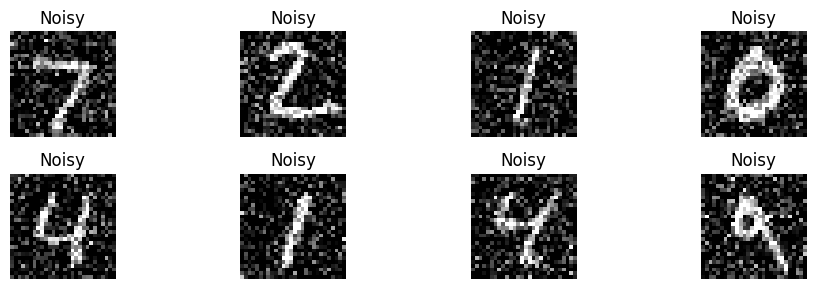

In [10]:
noise_factor = 0.3
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

plt.figure(figsize=(10, 3))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title('Noisy')
    plt.axis('off')
plt.tight_layout()
plt.show()

## 11. Accessing Model Parameters (Weights and Biases)

After training, you can inspect the learned parameters (weights and biases) of the model's layers. These parameters define what the model has learned from the data.


In [11]:
print('Accessing weights and biases from the first convolutional layer:')

# Get a specific layer by name or index
# Assuming 'conv2d' is the name of the first Conv2D layer in the autoencoder
# You can also use autoencoder.layers[1] if it's the second layer (Input layer is 0)
first_conv_layer = autoencoder.get_layer(index=1) # The first Conv2D layer after the Input layer

# Check if the layer has weights (kernel) and biases
if first_conv_layer.trainable_weights:
    weights, biases = first_conv_layer.get_weights()

    print(f'Shape of weights for {first_conv_layer.name}: {weights.shape}')
    print(f'Shape of biases for {first_conv_layer.name}: {biases.shape}')

    # Display a small portion of the weights and biases
    print('\nFirst 5x5 filter of weights (kernel):\n', weights[:,:,0,0][:5,:5])
    print('\nFirst 5 biases:\n', biases[:5])
else:
    print(f'Layer {first_conv_layer.name} does not have trainable weights.')


Accessing weights and biases from the first convolutional layer:
Shape of weights for conv2d: (3, 3, 1, 32)
Shape of biases for conv2d: (32,)

First 5x5 filter of weights (kernel):
 [[ 0.05076171  0.2566107   0.1167598 ]
 [ 0.06583926 -0.0900761   0.11279495]
 [ 0.15409726 -0.06455012 -0.13973463]]

First 5 biases:
 [ 0.00018176  0.02445701 -0.0002541   0.00059998  0.00122701]
